<a href="https://colab.research.google.com/github/Machoub/multilayer_perceptron/blob/main/mlp_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from google.colab import files
uploaded = files.upload()

Saving train_data.csv to train_data (1).csv
Saving test_data.csv to test_data (1).csv


In [ ]:
df = pd.read_csv('train_data.csv')
X = df.drop(columns=['diagnosis']).to_numpy().T
y = df['diagnosis'].to_numpy().reshape(-1, 1).T

y_one_hot = []
for label in y.flatten():
    if label == 0:
        y_one_hot.append([1, 0])
    elif label == 1:
        y_one_hot.append([0, 1])
y = np.array(y_one_hot).T

print(y)
print(y.shape)
print(X)
print(X.shape)

[[0 1 1 0 0 0 1 0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 0 1 0 1 0 1 0 0 1 1 0 0 1 1
  1 0 1 1 0 1 1 0 1 0 1 1 1 1 1 1 0 0 0 0 0 1 0 1 0 0 1 1 1 0 1 1 0 1 1 1
  0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 0 1 1 1 0 1
  0 0 0 1 1 1 1 1 0 1 1 0 0 1 0 1 0 1 1 0 1 1 0 0 1 1 1 1 0 1 0 1 1 0 0 1
  0 0 0 1 0 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0
  0 1 1 0 0 1 1 0 1 0 1 0 1 0 1 0 0 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 0 1 0 1
  1 0 1 0 1 0 0 0 1 1 0 1 1 0 0 1 1 0 0 0 1 0 1 1 1 1 1 1 1 0 0 1 0 1 1 0
  0 1 1 1 0 0 1 1 1 0 1 1 1 0 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 0 1
  0 0 0 1 0 0 0 1 1 1 1 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 1 0 1
  1 1 0 1 1 0 1 1 1 0 1 1 0 0 0 1 0 0 1 1 1 1 0 1 0 1 1 0 1 1 0 1 1 1 1 1
  1 1 0 1 1 1 1 0 0 0 1 0 1 0 1 1 0 0 1 1 0 1 0 0 0 1 1 0 1 1 0 1 1 0 1 0
  1 1 1 1 0 1 1 1 0 1 0 1 0 1 0 0 0 1 0 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1
  1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0]
 [1 0 0 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0

In [ ]:
# 1. Charger et nettoyer le fichier de test (Validation)
df_test = pd.read_csv('test_data.csv')

# --- Attention : Adapter selon ton fichier CSV ---
# Si ta colonne diagnosis est 'M'/'B', il faut mapper
if df_test['diagnosis'].dtype == 'object':
    df_test['diagnosis'] = df_test['diagnosis'].map({'M': 1, 'B': 0})

# 2. Séparer X et y
# On transpose (.T) pour avoir la forme (features, m_exemples) -> (30, m)
y_val = df_test['diagnosis'].values.reshape(1, -1)
X_val_raw = df_test.drop(columns=['diagnosis']).values.T

X_val = X_val_raw

print(f"X_val shape: {X_val.shape} | y_val shape: {y_val.shape}")

X_val shape: (30, 114) | y_val shape: (1, 114)


In [ ]:
def sigmoid(z, derivative=False):
    if derivative:
        return z * (1 - z)
    return 1 / (1 + np.exp(-z))

def relu(Z, derivative=False):
    if derivative:
        return np.where(Z > 0, 1, 0)
    return np.maximum(0, Z)

In [ ]:
def softmax(Z):

    e_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return e_Z / np.sum(e_Z, axis=0, keepdims=True)

In [ ]:
def network_archi(X, y):
    n_input = X.shape[0]
    n_output = y.shape[0]
    return n_input, 64, 32, 16, n_output

print(network_archi(X, y))

(30, 64, 32, 16, 2)


In [ ]:
def define_model(X, y):
    n_input, n_h1, n_h2, n_h3, n_output = network_archi(X, y)

    W1 = np.random.randn(n_h1, n_input)  * np.sqrt(2 / n_input)
    W2 = np.random.randn(n_h2, n_h1)    * np.sqrt(2 / n_h1)
    W3 = np.random.randn(n_h3, n_h2)    * np.sqrt(2 / n_h2)
    W4 = np.random.randn(n_output, n_h3) * np.sqrt(2 / n_h3)

    parameters = {
        'W1': W1, 'b1': np.zeros((n_h1, 1)),
        'W2': W2, 'b2': np.zeros((n_h2, 1)),
        'W3': W3, 'b3': np.zeros((n_h3, 1)),
        'W4': W4, 'b4': np.zeros((n_output, 1)),
    }
    return parameters

params = define_model(X, y)
print(params)

{'W1': array([[ 0.19286223, -0.09106795,  0.20405598, ..., -0.19322897,
         0.05578632,  0.1232861 ],
       [-0.33612907,  0.30557635,  0.04509965, ...,  0.33844558,
         0.0007206 , -0.27851731],
       [ 0.02745764,  0.28312009, -0.30661936, ...,  0.02798653,
        -0.5319414 ,  0.11757052],
       ...,
       [-0.2625492 , -0.05445761,  0.35582375, ..., -0.07604246,
         0.12748583, -0.10636803],
       [ 0.08177462, -0.56070262, -0.07568509, ..., -0.08729704,
        -0.60435023, -0.03253324],
       [ 0.00924826,  0.04984148, -0.3359855 , ..., -0.13433765,
         0.33071804,  0.24047056]]), 'b1': array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0

In [ ]:
def forward_propagation(X, parameters):
    W1, b1 = parameters['W1'], parameters['b1']
    W2, b2 = parameters['W2'], parameters['b2']
    W3, b3 = parameters['W3'], parameters['b3']
    W4, b4 = parameters['W4'], parameters['b4']

    Z1 = np.dot(W1, X) + b1;  A1 = relu(Z1)
    Z2 = np.dot(W2, A1) + b2; A2 = relu(Z2)
    Z3 = np.dot(W3, A2) + b3; A3 = relu(Z3)
    Z4 = np.dot(W4, A3) + b4; A4 = softmax(Z4)

    cache = {'Z1': Z1, 'A1': A1,
             'Z2': Z2, 'A2': A2,
             'Z3': Z3, 'A3': A3,
             'Z4': Z4, 'A4': A4}
    return cache

In [ ]:
shapes = forward_propagation(X, params)
print(shapes)

def backward_propagation(X, y, parameters, cache):
    m = X.shape[1]
    W2, W3, W4 = parameters['W2'], parameters['W3'], parameters['W4']
    A1, A2, A3, A4 = cache['A1'], cache['A2'], cache['A3'], cache['A4']
    Z1, Z2, Z3 = cache['Z1'], cache['Z2'], cache['Z3']

    dZ4 = A4 - y
    dW4 = (1/m) * np.dot(dZ4, A3.T)
    db4 = (1/m) * np.sum(dZ4, axis=1, keepdims=True)

    dZ3 = np.dot(W4.T, dZ4) * relu(Z3, derivative=True)
    dW3 = (1/m) * np.dot(dZ3, A2.T)
    db3 = (1/m) * np.sum(dZ3, axis=1, keepdims=True)

    dZ2 = np.dot(W3.T, dZ3) * relu(Z2, derivative=True)
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = np.dot(W2.T, dZ2) * relu(Z1, derivative=True)
    dW1 = (1/m) * np.dot(dZ1, X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

    return {'dW1': dW1, 'db1': db1,
            'dW2': dW2, 'db2': db2,
            'dW3': dW3, 'db3': db3,
            'dW4': dW4, 'db4': db4}

def update_parameters(parameters, grads, lr):
    for key in ['W1', 'b1', 'W2', 'b2', 'W3', 'b3', 'W4', 'b4']:
        parameters[key] -= lr * grads['d' + key]
    return parameters

{'Z1': array([[ 0.92030992, -0.3055276 ,  0.93502957, ...,  1.37259937,
        -0.14859156, -0.20614206],
       [ 0.8089881 , -0.5963312 ,  0.2791314 , ...,  1.06590435,
         0.22092266,  0.59158274],
       [ 2.48864108,  0.87395425,  0.43074015, ...,  3.77011418,
         1.79447206, -1.99620344],
       ...,
       [ 0.66163796,  0.74157879,  0.35508772, ...,  0.60688107,
         0.47944326,  0.17640832],
       [-0.5322643 ,  1.70119607,  0.03123888, ...,  0.81984902,
         0.389464  ,  0.0984105 ],
       [ 1.06307579, -0.55611744,  0.59658417, ...,  0.34718343,
         0.47960039,  0.9907006 ]]), 'A1': array([[0.92030992, 0.        , 0.93502957, ..., 1.37259937, 0.        ,
        0.        ],
       [0.8089881 , 0.        , 0.2791314 , ..., 1.06590435, 0.22092266,
        0.59158274],
       [2.48864108, 0.87395425, 0.43074015, ..., 3.77011418, 1.79447206,
        0.        ],
       ...,
       [0.66163796, 0.74157879, 0.35508772, ..., 0.60688107, 0.47944326,
      

In [ ]:
def compute_cost(A3, Y):
    m = Y.shape[1]
    # Cross-Entropy formule
    cost = - (1/m) * np.sum(Y * np.log(A3 + 1e-8))
    return np.squeeze(cost) # S'assure que c'est un chiffre, pas un tableau

def compute_accuracy(A, Y):
    # A et Y sont de forme (2, 455)

    # On prend l'index du max (0 ou 1) pour chaque colonne
    predictions = np.argmax(A, axis=0)
    labels = np.argmax(Y, axis=0)

    # On compare : ça renvoie un tableau de True/False
    # np.mean calcule le pourcentage de True
    accuracy = np.mean(predictions == labels)

    return accuracy

In [ ]:
def mlp(X, y, X_val, y_val, epochs=200, lr=0.1):
    params = define_model(X, y)
    history = {'train_cost': [], 'train_acc': [], 'val_acc': []}

    for i in range(epochs):
        # Train
        cache = forward_propagation(X, params)
        cost  = compute_cost(cache['A4'], y)
        acc   = compute_accuracy(cache['A4'], y)

        # Validation
        val_cache = forward_propagation(X_val, params)
        val_acc   = compute_accuracy(val_cache['A4'], y_val)

        history['train_cost'].append(cost)
        history['train_acc'].append(acc)
        history['val_acc'].append(val_acc)

        grads  = backward_propagation(X, y, params, cache)
        params = update_parameters(params, grads, lr)

        if i % 10 == 0:
            print(f"Epoch {i:3d} | Loss: {cost:.4f} | Train: {acc:.2%} | Val: {val_acc:.2%}")

        # Early stopping si gap trop grand (overfitting)
        if acc - val_acc > 0.08:
            print(f"⚠️ Overfitting détecté à l'epoch {i}, arrêt.")
            break

    return params, history

(2, 114)
Epoch   0 | Loss: 0.8815 | Train: 42.20% | Val: 46.49%
Epoch  10 | Loss: 0.1493 | Train: 95.82% | Val: 93.86%
Epoch  20 | Loss: 0.0990 | Train: 96.92% | Val: 94.74%
Epoch  30 | Loss: 0.0775 | Train: 97.14% | Val: 94.74%
Epoch  40 | Loss: 0.0658 | Train: 97.14% | Val: 94.74%
Epoch  50 | Loss: 0.0571 | Train: 97.80% | Val: 95.61%
Epoch  60 | Loss: 0.0507 | Train: 98.02% | Val: 96.49%
Epoch  70 | Loss: 0.0456 | Train: 98.24% | Val: 96.49%
Epoch  80 | Loss: 0.0412 | Train: 98.46% | Val: 96.49%


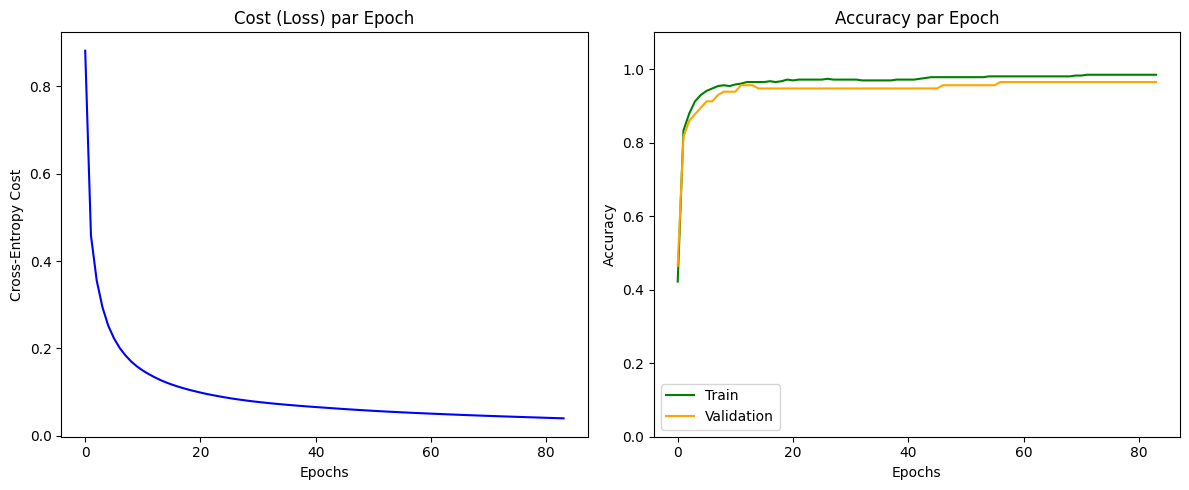

In [ ]:
y_val_oh = np.eye(2)[y_val.flatten()].T

print(y_val_oh.shape)
model, history = mlp(X, y, X_val, y_val_oh, epochs=84, lr=0.1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Graphique 1 : La Loss
ax1.plot(history['train_cost'], color='blue')
ax1.set_title('Cost (Loss) par Epoch')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Cross-Entropy Cost')

# Graphique 2 : Train vs Val Accuracy
ax2.plot(history['train_acc'], color='green', label='Train')
ax2.plot(history['val_acc'],   color='orange', label='Validation')
ax2.set_title('Accuracy par Epoch')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.1)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
np.save('saved_model.npy', model)
# ```

# **Mini-batch** — le sujet donne `batch_size=8` en exemple, tu fais du full-batch en ce moment.

# **Affichage epoch par epoch** dans le terminal comme ça :
# ```
# epoch 01/84 - loss: 0.6882 - val_loss: 0.6788

In [ ]:
model = np.load('saved_model.npy', allow_pickle=True).item()
print(model)

{'W1': array([[ 0.10162068,  0.48147646, -0.20705381, ..., -0.09714769,
        -0.65350239, -0.40639169],
       [-0.26168724, -0.35010512,  0.30156763, ...,  0.35729784,
         0.06179037, -0.08014538],
       [ 0.12550594,  0.17259187, -0.63808164, ...,  0.19046515,
         0.2844228 , -0.39151816],
       ...,
       [ 0.48286467, -0.2140908 , -0.18511779, ..., -0.26814193,
         0.03737494, -0.40898064],
       [-0.24849222,  0.46192166,  0.11031124, ...,  0.15170206,
        -0.22793845, -0.22272022],
       [ 0.55208864, -0.02393776,  0.35952118, ...,  0.25142905,
        -0.19079909, -0.07260078]]), 'b1': array([[ 0.00451381],
       [ 0.01557881],
       [ 0.0197755 ],
       [ 0.01771599],
       [ 0.00903575],
       [-0.02461324],
       [ 0.06484358],
       [ 0.00435358],
       [-0.00940301],
       [-0.00873185],
       [-0.02922586],
       [ 0.0038995 ],
       [-0.00872188],
       [ 0.00269197],
       [-0.00431323],
       [ 0.01498868],
       [ 0.02355046],

In [ ]:
# ===============================
# 2. Charger les données de test
# ===============================
df_test = pd.read_csv('test_data.csv')
print(df_test.shape)

y_true = df_test['diagnosis'].values
X_test = df_test.drop(columns=['diagnosis']).to_numpy().T  # (30, 114)

# ===============================
# 3. Fonctions nécessaires
# ===============================
def relu(Z, derivative=False):
    if derivative:
        return np.where(Z > 0, 1, 0)
    return np.maximum(0, Z)

def softmax(Z):
    e_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return e_Z / np.sum(e_Z, axis=0, keepdims=True)

def forward_propagation(X, parameters):
    W1, b1 = parameters['W1'], parameters['b1']
    W2, b2 = parameters['W2'], parameters['b2']
    W3, b3 = parameters['W3'], parameters['b3']
    W4, b4 = parameters['W4'], parameters['b4']

    Z1 = np.dot(W1, X) + b1;  A1 = relu(Z1)
    Z2 = np.dot(W2, A1) + b2; A2 = relu(Z2)
    Z3 = np.dot(W3, A2) + b3; A3 = relu(Z3)
    Z4 = np.dot(W4, A3) + b4; A4 = softmax(Z4)

    return A4

# ===============================
# 4. Prédiction
# ===============================
A4 = forward_propagation(X_test, model)

# A4 shape : (2, 114) → proba [benign, malignant]
predictions = np.argmax(A4, axis=0)  # 0 = Benign, 1 = Malignant

# ===============================
# 5. Évaluation
# ===============================
accuracy = np.mean(predictions == y_true)

# Binary cross-entropy (formule du sujet)
proba_malignant = A4[1, :]  # probabilité classe 1
bce = -np.mean(y_true * np.log(proba_malignant + 1e-8) +
               (1 - y_true) * np.log(1 - proba_malignant + 1e-8))

print(f"\n{'='*40}")
print(f"  Accuracy       : {accuracy:.2%}")
print(f"  Binary CE Loss : {bce:.4f}")
print(f"{'='*40}")

# ===============================
# 6. Détail par sample (optionnel)
# ===============================
labels = {0: 'Benign (B)', 1: 'Malignant (M)'}
print("\nAperçu des 10 premières prédictions :")
print(f"{'Index':<8} {'Prédit':<15} {'Réel':<15} {'Correct'}")
print("-" * 45)
for i in range(80):
    pred_label = labels[predictions[i]]
    true_label = labels[y_true[i]]
    correct    = "✅" if predictions[i] == y_true[i] else "❌"
    print(f"{i:<8} {pred_label:<15} {true_label:<15} {correct}")

(114, 31)

  Accuracy       : 95.61%
  Binary CE Loss : 0.0872

Aperçu des 10 premières prédictions :
Index    Prédit          Réel            Correct
---------------------------------------------
0        Benign (B)      Benign (B)      ✅
1        Malignant (M)   Malignant (M)   ✅
2        Malignant (M)   Benign (B)      ❌
3        Malignant (M)   Malignant (M)   ✅
4        Benign (B)      Benign (B)      ✅
5        Benign (B)      Benign (B)      ✅
6        Malignant (M)   Malignant (M)   ✅
7        Benign (B)      Benign (B)      ✅
8        Benign (B)      Benign (B)      ✅
9        Benign (B)      Benign (B)      ✅
10       Malignant (M)   Malignant (M)   ✅
11       Benign (B)      Benign (B)      ✅
12       Malignant (M)   Malignant (M)   ✅
13       Benign (B)      Benign (B)      ✅
14       Benign (B)      Benign (B)      ✅
15       Benign (B)      Benign (B)      ✅
16       Benign (B)      Malignant (M)   ❌
17       Benign (B)      Benign (B)      ✅
18       Malignant (M)   Beni